In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)


In [ ]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [ ]:
print(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


In [ ]:
df['target'] = data.target

In [102]:
from operator import xor
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# KFold
kfold = KFold(n_splits=4, shuffle=True, random_state=42)

model = DecisionTreeClassifier(criterion="gini", random_state=30, max_depth = 3, min_samples_leaf=4, min_samples_split=6)

train_acc = []
test_acc = []

last_model = None
last_X_test = None
last_y_test = None
last_pred = None

# KFold Training
for train_index, test_index in kfold.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Train
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Accuracy
    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

    # Save last fold
    last_model = model
    last_X_test = X_test
    last_y_test = y_test
    last_pred = test_pred

# Average Accuracy
print("Average Training Accuracy :", np.mean(train_acc))
print("Average Testing Accuracy  :", np.mean(test_acc))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(last_y_test, last_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(last_y_test, last_pred))





Average Training Accuracy : 0.9654388077096457
Average Testing Accuracy  : 0.9419629666108539

Confusion Matrix:
[[53  7]
 [ 0 82]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        60
           1       0.92      1.00      0.96        82

    accuracy                           0.95       142
   macro avg       0.96      0.94      0.95       142
weighted avg       0.95      0.95      0.95       142



In [114]:
    X_train = X.iloc[tr]
    X_test = X.iloc[te]

    y_train = y.iloc[tr]
    y_test = y.iloc[te]

    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"Fold {1}")
    print("Training Accuracy :", train_score)
    print("Testing Accuracy  :", test_score)
    print()

Fold 1
Training Accuracy : 0.9672131147540983
Testing Accuracy  : 0.9507042253521126



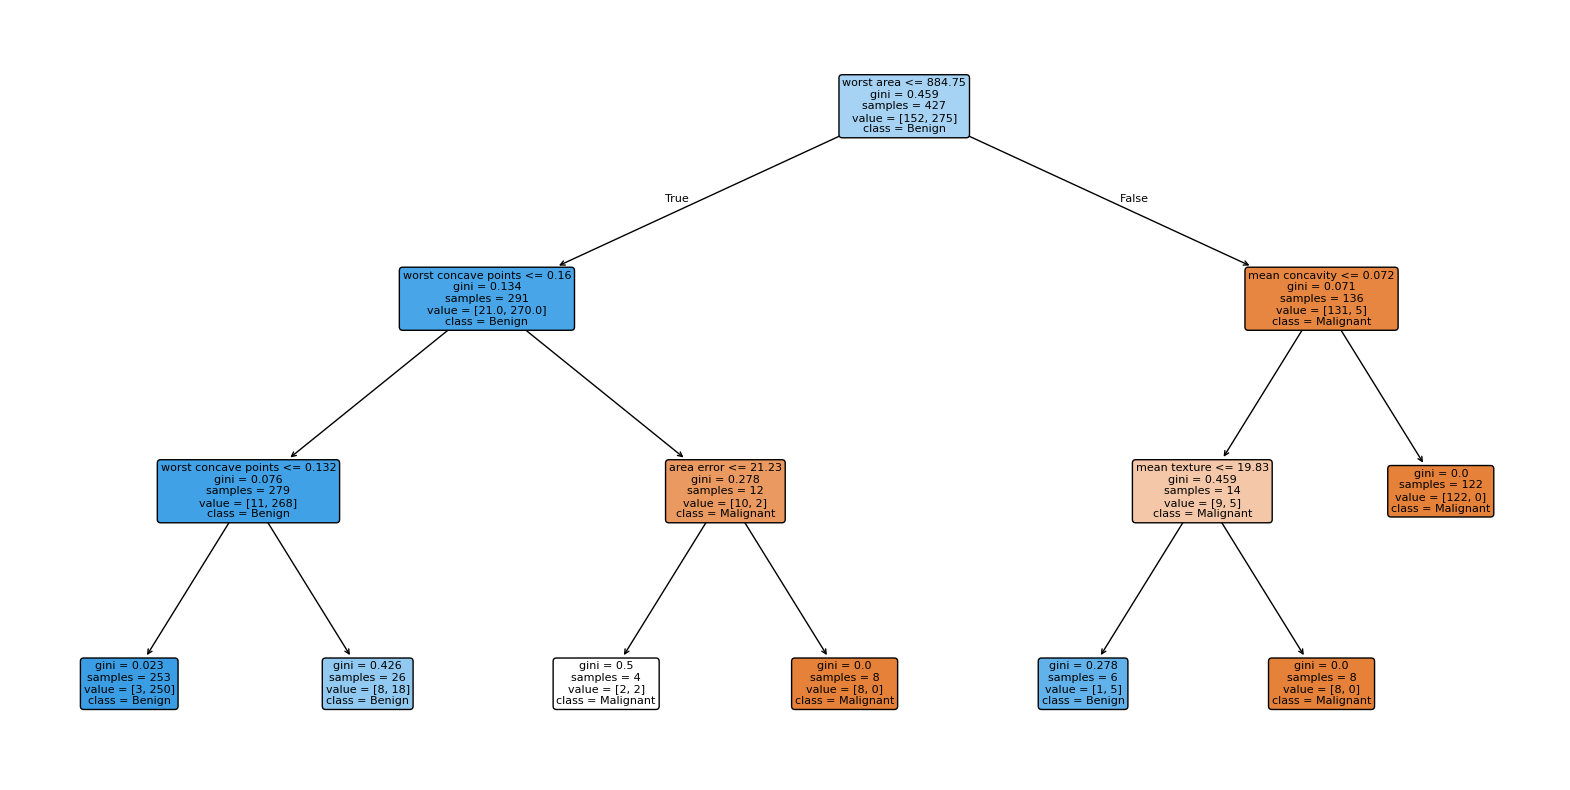

In [113]:
#Visualisation
plt.figure(figsize=(20,10))

plot_tree(
    last_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

#Visualisation
plt.figure(figsize=(20,10))

plot_tree(
    last_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()